# DX 704 Week 3 Project

This week's project will give you practice with optimizing choices for bandit algorithms.
You will be given access to the bandit problem via a blackbox object, and you will investigate the bandit rewards to pick a suitable algorithm.

The full project description, a template notebook and supporting code are available on GitHub: [Project 3 Materials](https://github.com/bu-cds-dx704/dx704-project-03).


## Example Code

You may find it helpful to refer to these GitHub repositories of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples
* https://github.com/bu-cds-omds/dx603-examples
* https://github.com/bu-cds-omds/dx704-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Part 1: Pick a Bandit Algorithm

Experiment with the multi-armed bandit interface using seed 0 to learn about the distribution of rewards and decide what kind of bandit algorithm will be appropriate.
A histogram will likely be helpful.

In [1]:
# DO NOT CHANGE

import numpy as np

class BanditProblem(object):
    def __init__(self, seed):
        self.seed = seed
        self.rng = np.random.default_rng(seed)

        self.num_arms = 3
        self.ns = self.rng.integers(low=1, high=10, size=self.num_arms)
        self.ps = self.rng.uniform(low=0.2, high=0.4, size=self.num_arms)

    def get_num_arms(self):
        return self.num_arms

    def get_reward(self, arm):
        if arm < 0 or arm >= self.num_arms:
            raise ValueError("Invalid arm")

        x = self.rng.uniform()
        x *= self.rng.binomial(self.ns[arm], self.ps[arm])

        return x


In [2]:
bandit0 = BanditProblem(0)

In [3]:
bandit0.get_num_arms()

3

In [4]:
bandit0.get_reward(arm=0)

1.8255111545554434

Arm 0: min=0.000, mean=0.815, max=4.066, unique=845
Arm 1: min=0.000, mean=0.573, max=4.408, unique=725
Arm 2: min=0.000, mean=0.926, max=4.886, unique=890


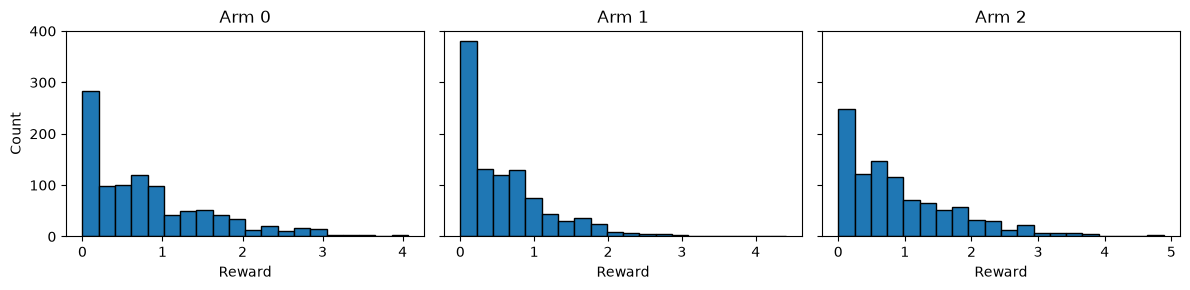

In [5]:
# YOUR CHANGES HERE

import matplotlib.pyplot as plt

# Reset the bandit so the investigation always starts from seed 0
bandit0 = BanditProblem(0)

samples = {}

for arm in range(bandit0.get_num_arms()):
    samples[arm] = np.array([
        bandit0.get_reward(arm)
        for _ in range(1000)
    ])

    print(
        f"Arm {arm}: min={samples[arm].min():.3f}, "
        f"mean={samples[arm].mean():.3f}, "
        f"max={samples[arm].max():.3f}, "
        f"unique={len(np.unique(samples[arm]))}"
    )

fig, axes = plt.subplots(
    1,
    bandit0.get_num_arms(),
    figsize=(12, 3),
    sharey=True
)

for arm, axis in enumerate(axes):
    axis.hist(samples[arm], bins=20, edgecolor="black")
    axis.set_title(f"Arm {arm}")
    axis.set_xlabel("Reward")

axes[0].set_ylabel("Count")

fig.tight_layout()
plt.show()

Based on your investigation, pick an appropriate bandit algorithm to implement from the algorithms covered this week.
Write a file "algorithm-choice.txt" that states your choice and give a single sentence justifying your choice and rejecting the alternatives.
Keep your explanation concise; you should be able to justify your choice solely based on the type of numbers observed, and whether those match the bandit algorithms that you have learned.

## Part 2: Implement Bandit

Based on your decision, implement an appropriate bandit algorithm and pick 1000 actions using seed 2026.

In [6]:
# YOUR CHANGES HERE
import pandas as pd

# Fresh bandit and separate random generator for action choices
bandit = BanditProblem(2026)
action_rng = np.random.default_rng(2026)

num_arms = bandit.get_num_arms()
num_actions = 1000
epsilon = 0.1

counts = np.zeros(num_arms, dtype=int)
mean_rewards = np.zeros(num_arms)
history = []

for t in range(num_actions):

    if t < num_arms:
        # Try each arm once
        action = t

    elif action_rng.random() < epsilon:
        # Explore: select any arm uniformly at random
        action = int(action_rng.integers(num_arms))

    else:
        # Exploit: select the highest estimated mean, breaking ties randomly
        best_arms = np.flatnonzero(
            mean_rewards == mean_rewards.max()
        )
        action = int(action_rng.choice(best_arms))

    reward = bandit.get_reward(action)

    # Update the selected arm's count and running average
    counts[action] += 1
    mean_rewards[action] += (
        reward - mean_rewards[action]
    ) / counts[action]

    history.append((action, reward))

history_df = pd.DataFrame(history, columns=["action", "reward"])

print(f"Total actions: {len(history_df)}")
print(f"Total reward: {history_df['reward'].sum():.4f}")

for arm in range(num_arms):
    print(
        f"Arm {arm}: selected {counts[arm]} times, "
        f"mean reward = {mean_rewards[arm]:.4f}"
    )

history_df.head(10)

Total actions: 1000
Total reward: 1143.0169
Arm 0: selected 939 times, mean reward = 1.2046
Arm 1: selected 25 times, mean reward = 0.2485
Arm 2: selected 36 times, mean reward = 0.1585


,action,reward
0,0,3.162073
1,1,0.177353
2,2,0.298303
3,0,2.759550
4,0,1.505464
5,0,1.651791
6,0,0.677625
7,0,0.452666
8,0,1.292736
9,0,0.025681


Write a file "history.tsv" with columns action and reward in the order that the actions were taken.

In [7]:
# YOUR CHANGES HERE

history_df.to_csv("history.tsv", sep="\t", index=False)


print(f"Wrote {len(history)} rows to history.tsv.")

Wrote 1000 rows to history.tsv.


Submit "history.tsv" in Gradescope.

## Part 3: Action Statistics

Based on the data from part 2, estimate the expected reward for each arm and write a file "actions.tsv" with the columns action, min_reward, mean_reward, max_reward.

In [8]:
# YOUR CHANGES HERE

actions_df = (
    history_df.groupby("action")["reward"]
    .agg(
        min_reward="min",
        mean_reward="mean",
        max_reward="max"
    )
    .reset_index()
)

actions_df

,action,min_reward,mean_reward,max_reward
0,0,0.0,1.204577,6.564312
1,1,0.0,0.248460,0.873965
2,2,0.0,0.158546,0.957842


In [9]:
actions_df.to_csv("actions.tsv", sep="\t", index=False)

Submit "actions.tsv" in Gradescope.

## Part 4: Regret Estimates

Estimate the regret taking 1000 actions with the following strategies.

* uniform: Pick an arm uniformly at random.
* just-i: Always pick arm $i$. Do this for $i=0$ to $K-1$ where $K$ is the number of arms.
* actual: This should match your output in part 2.

These estimates should be based on your previous action statistics; you should not use the true action values from the bandit code.

In [10]:
# YOUR CHANGES HERE

# Estimated expected rewards from Part 3
estimated_means = actions_df.set_index("action")["mean_reward"]
best_mean = estimated_means.max()
num_actions = len(history_df)

results = []

# Uniform: each arm has an equal probability of selection
uniform_regret = num_actions * (
    best_mean - estimated_means.mean()
)
results.append(("uniform", uniform_regret))

# Just-i: always select the same arm
for arm in estimated_means.index:
    regret = num_actions * (
        best_mean - estimated_means.loc[arm]
    )
    results.append((f"just-{arm}", regret))

# Actual: use the action counts from our Part 2 experiment
action_counts = (
    history_df["action"]
    .value_counts()
    .reindex(estimated_means.index, fill_value=0)
)

actual_regret = (
    action_counts * (best_mean - estimated_means)
).sum()

results.append(("actual", actual_regret))

strategies_df = pd.DataFrame(
    results,
    columns=["strategy", "regret"]
)

strategies_df

,strategy,regret
0,uniform,667.382859
1,just-0,0.000000
2,just-1,956.117343
3,just-2,1046.031235
4,actual,61.560058


Write your results to a file "strategies.tsv" with the columns strategy and regret.

In [11]:
# YOUR CHANGES HERE

strategies_df.to_csv("strategies.tsv", sep="\t", index=False)

Submit "strategies.tsv" in Gradescope.

## Part 5: Acknowledgments

Make a file "acknowledgments.txt" documenting any outside sources or help on this project.
If you discussed this assignment with anyone, please acknowledge them here.
If you used any libraries not mentioned in this module's content, please list them with a brief explanation what you used them for.
If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the generative AI policy.
If no acknowledgements are appropriate, just write none in the file.


Submit "acknowledgments.txt" in Gradescope.

## Part 6: Code

Please submit a Jupyter notebook that can reproduce all your calculations and recreate the previously submitted files.

Submit "project.ipynb" in Gradescope.